# MNIST example

# Setting Up the Hardware Accelerator on Colab
Before we even start writing any Python code, we need to first set up Colab’s runtime environment to use GPUs or TPUs instead of CPUs. Colab’s notebooks use CPUs by default — to change the runtime type to GPUs or TPUs, select “Change runtime type” under “Runtime” from Colab’s menu bar.

## Libs

In [18]:
import tensorflow as tf
import numpy as np
import pandas as pd

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# The dimensions of the training feature set (the images)
print(f'Training set dimensions: {x_train.shape}')
print(f'Test set dimensions: {x_test.shape}')

# The x data is a 3-d array (images, width, height) of grayscale values. The y data is an integer vector with values ranging from 0 to 9.

11490434/11490434 [==============================] - 0s 0us/step
Training set dimensions: (60000, 28, 28)
Test set dimensions: (10000, 28, 28)


# Data prepare
These images are not in the the correct shape as tensors, as the number of channels is missing.

In [3]:
# Reshape the data
img_rows, img_cols = 28, 28
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)

# Print the new shape to verify
print(f'New training set shape: {x_train.shape}')
print(f'New test set shape: {x_test.shape}')

New training set shape: (60000, 28, 28, 1)
New test set shape: (10000, 28, 28, 1)


The data must be normalized. Since the pixel values represent brigness on a scale from 0 (black) to 255 (white), they can all be rescaled by dividing each by the maximum value of 255.

In [4]:
# Normalize the images to the range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

To prepare this data for training we one-hot encode the vectors into binary class matrices using the Keras `to_categorical()` function. One hot encoding is a vector representation where all elements of the vector are 0 except one, which has 1 as its value (assigning 1 to working feature and 0’s to other idle features).

In [5]:
# Number of classes
num_classes = 10

# One-hot encode the labels
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# Print the shape to verify
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

y_train shape: (60000, 10)
y_test shape: (10000, 10)


In [ ]:
# 9 first encoded digits from trainig set are below (the first column corresponds to zero, second to one, etc.):
y_train[:9]

# Defining the model

In [ ]:
# Define the model
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape), # (3 * 3 * 1 + 1) * 32 = 320
    # (filter_rows * filter_cols * filters_previous_layer + 1) * filters
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'), # (3 * 3 * 32 + 1) * 64 = 18 496
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    Flatten(), #5 * 5 * 64 neurons
    Dense(64, activation='relu'), #1600 * 64 + 64 = 102 464
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # 64 * 10 + 10 = 650
])

# Display the model's architecture
model.summary()

# Compile the model
* Loss function -- This measures how accurate the model is during training. We want to minimize this function to 'steer' the model in the right direction.
* Optimizer -- This is how the model is updated based on the data it sees and its loss function.
* Metrics -- Used to monitor the training and testing steps. The following example uses accuracy, the fraction of the digits that are correctly classified.

In [9]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

# Training the model
A mini-batch size of 128 will allow the tensors to fit into the memory most of NVidia graphics processing unit. The model will run over 15 epochs, with a validation split set at 0.2.

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=15, # Number of epochs
    batch_size=128,  # Size of batch in a single step
    validation_split=0.2  # Percent of data in validation set
)

# Plot the training history
plt.figure(figsize=(12, 8))

# Plot training & validation accuracy values
plt.subplot(2, 1, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(2, 1, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Evaluate the model

In [11]:
# Evaluate the model's performance on the training data
train_loss, train_accuracy = model.evaluate(x_train, y_train, verbose=0)
print(f'Train accuracy: {train_accuracy:.4f}, Train loss: {train_loss:.4f}')

# Evaluate the model's performance on the test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}')


Train accuracy: 0.9966, Train loss: 0.0136
Test accuracy: 0.9921, Test loss: 0.0284


# Predictions

In [ ]:
# Predict probabilities on test data
predictions = model.predict(x_test)

# Convert predicted probabilities to class labels
predicted_digits = np.argmax(predictions, axis=1)

# Print the first few predicted digits to verify
print(predicted_digits[:10])

A prediction is an array of 10 numbers. These describe the 'confidence' of the model that the image corresponds to each of the 10 different digits. Let's plot several images with their predictions. Correct prediction labels are green and incorrect prediction labels are red.

In [ ]:
# Plot the first 25 images with their predicted and actual labels
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Get the image and true label
    img = x_test[i].reshape(28, 28)
    true_label = np.argmax(y_test[i])
    predicted_label = predicted_digits[i]

    # Set the title color based on the prediction correctness
    color = '#008800' if predicted_label == true_label else '#bb0000'

    # Plot the image
    plt.imshow(img, cmap=plt.cm.binary)
    plt.title(f'{predicted_label} ({true_label})', color=color)
plt.show()

# Confusion matrix

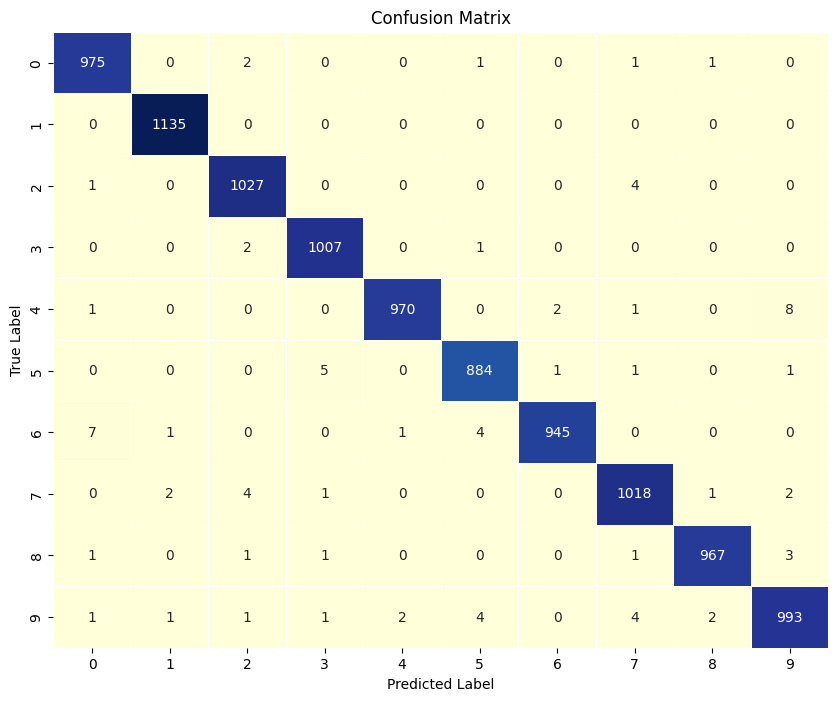

In [17]:
# Create a confusion matrix
conf_matrix = confusion_matrix(np.argmax(y_test, axis=1), predicted_digits)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu", cbar=False, linewidths=.5)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Exercise 1 (Fashion MNIST) - 30 minutes

# Exercise 2 (CIFAR-10) - 45 minutes
The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class.

The classes are completely mutually exclusive. There is no overlap between automobiles and trucks. "Automobile" includes sedans, SUVs, things of that sort. "Truck" includes only big trucks. Neither includes pickup trucks.